# Sheet 1: Dataset Analysis
##  a) Read the dataset description and briefly summarize

**users.dat**  
This file contains 6040 users, it contains UserID, Gender (M/F), Age, Occupation and Zip-code.   
**ratings.dat**  
This file contains 1000209 ratings which consists of UserID, MovieID, Rating and Timestamp.  
**movies.dat**  
File file contains 3883 movies with MovieID, Title and Genres. 



## b) Analyze the ratings
Find suitable ways to visualize the data, and  
interpret the results. Specifically, consider the following aspects:   
compute sparsity of the user-item matrix.  
• Plot the rating distribution.  
• Plot the number of interactions per user.  
• Plot the number of interactions per item.  
• Briefly interpret what these distributions imply for recommender systems.

In [82]:
import pandas as pd

df_rating = pd.read_csv("./data/ratings.dat", 
                 sep='::', 
                 names=['User-ID','Movie-ID', 'Rating', 'Timestamp'], 
                 header=None)


C:\Users\jonas\AppData\Local\Temp\ipykernel_32248\3433687705.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_rating = pd.read_csv("./data/ratings.dat",


In [83]:
# small sample of data
print(df_rating.iloc[0:3])

   User-ID  Movie-ID  Rating  Timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968


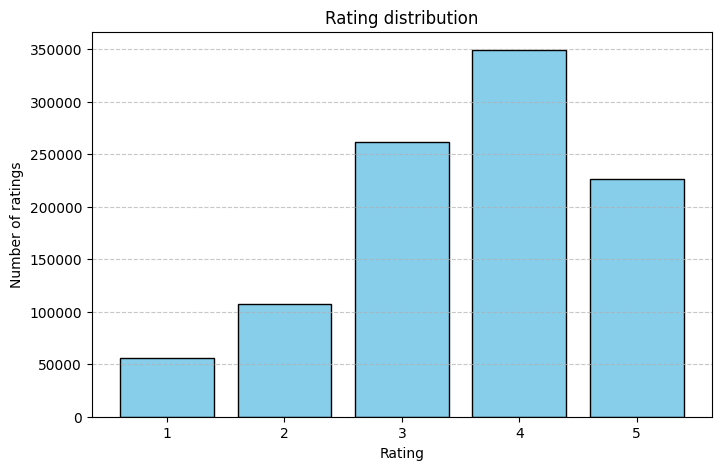

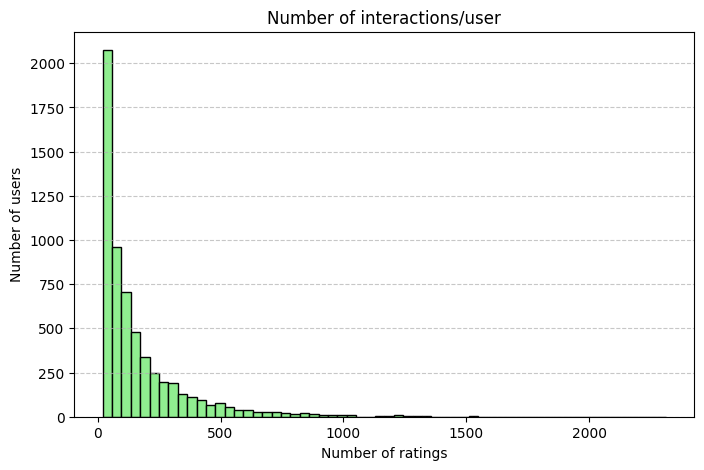

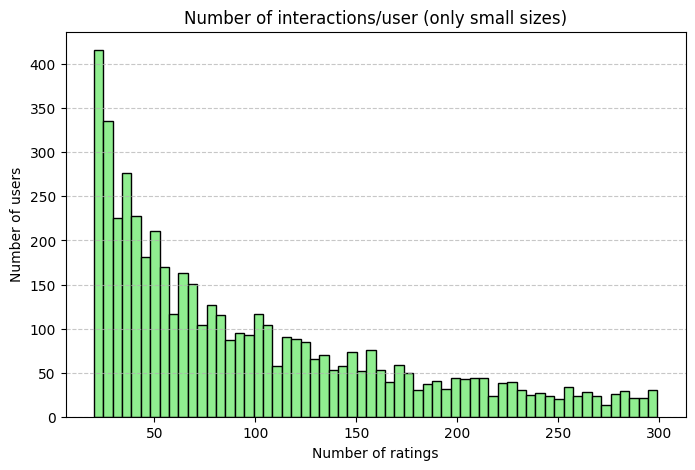

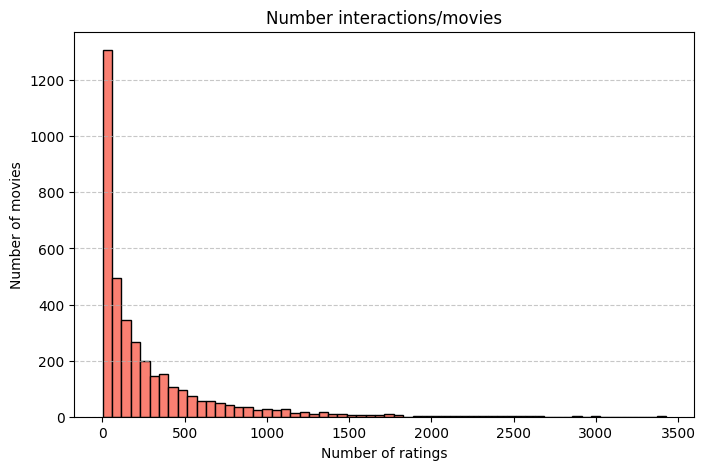

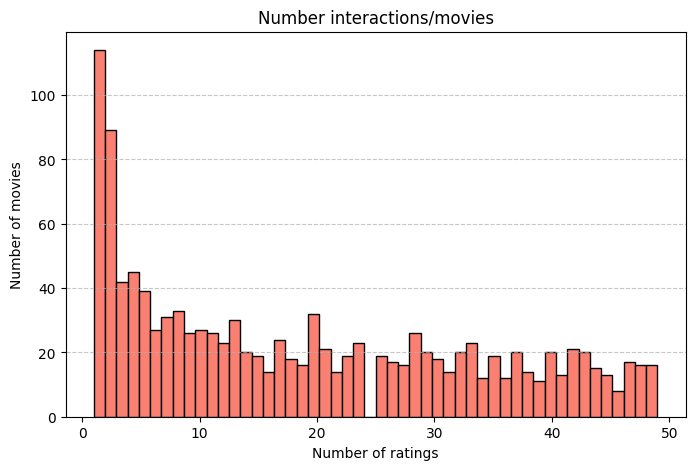

average rating is:  3.581564453029317
average rating/user 165.5975165562914
average rating/movie 257.5866597991244


In [84]:
import matplotlib.pyplot as plt 
ratings = df_rating['Rating'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(ratings.index, ratings.values, color='skyblue', edgecolor='black')
plt.title('Rating distribution')
plt.xlabel('Rating')
plt.ylabel('Number of ratings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 2. Interactions per User ---
user_counts = df_rating.groupby('User-ID').size()

plt.figure(figsize=(8, 5))
plt.hist(user_counts, bins=60, color='lightgreen', edgecolor='black')
plt.title('Number of interactions/user')
plt.xlabel('Number of ratings')
plt.ylabel('Number of users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

filtered_user_counts = user_counts[user_counts < 300]
plt.figure(figsize=(8, 5))
plt.hist(filtered_user_counts, bins=60, color='lightgreen', edgecolor='black')
plt.title('Number of interactions/user (only small sizes)')
plt.xlabel('Number of ratings')
plt.ylabel('Number of users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 3. Interactions per Item (Movie) ---
movie_counts = df_rating.groupby('Movie-ID').size()

plt.figure(figsize=(8, 5))
plt.hist(movie_counts, bins=60, color='salmon', edgecolor='black')
plt.title('Number interactions/movies')
plt.xlabel('Number of ratings')
plt.ylabel('Number of movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


movie_counts_filtered = movie_counts[movie_counts < 50]
plt.figure(figsize=(8, 5))
plt.hist(movie_counts_filtered, bins=50, color='salmon', edgecolor='black')
plt.title('Number interactions/movies')
plt.xlabel('Number of ratings')
plt.ylabel('Number of movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("average rating is: ", df_rating["Rating"].sum() / 1000209)
print("average rating/user", user_counts.sum() /6040)
print("average rating/movie", movie_counts.sum()/3883)



### interpretation
**Sparsity**  
We have 6040 users and 3883 moves this means the matrix has 6040*3883=23453320 entries but we only have 1000209 ratings this means roughly 4.26% are populated. (in comparison to real life data sets quite big)

\textbf{interpretation of graphs}
From the rating distribution we can see that the most common rating are 4 stars and the average is 3.6 "stars". 

From the ratings/user we can see that therea are no users with less than 20 ratings, this probably means that this is a filtered list. In this list lower ratings (above 20) are most common. 
The average rating is 165.6 ratings. 


From the Number interactions/movie we can also see that only a few movies have a lot of ratings and most of them have little interaction. The average is 257.6 ratings/movie. 

**implications for recommender systems**  
Because of the already filtered list with ratings more than 20 we don't have the cold start problem (at least not for the users in the database, for new ones this still exists
). Because every user has already voted on 20 films we can find similar users and make good recommendations. What is interesting is that the average rating is quite high. This means its difficult to differentiate between good films and very good films because there is no higher resolution than 4,5 stars. The range is bigger for low rated films. 

Also all the distribution match the long tail distribution. This means there are a few movies with a lot of ratings but most of them have just a few. This is also true for the users, most of them only vote for a few films but there are some of them which vote a lot. 





## Analyze the user information (users.dat):
• Distribution of age groups, gender, occupation.  
• Discuss which attributes could be useful for recommendation and why.

In [85]:
#This file contains 6040 users, it contains UserID, Gender (M/F), Age, Occupation and Zip-code. 
df_users = pd.read_csv("./data/users.dat", 
                 sep='::', 
                 names=['User-ID','Gender', 'Age', 'Occupation', 'Zip-Code'], 
                 header=None)

C:\Users\jonas\AppData\Local\Temp\ipykernel_32248\1576940509.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_users = pd.read_csv("./data/users.dat",


Small sample: 
   User-ID Gender  Age  Occupation Zip-Code
0        1      F    1          10    48067
1        2      M   56          16    70072 

Gender distribution
There are  1709  females and  4331  males
Age distribution: 


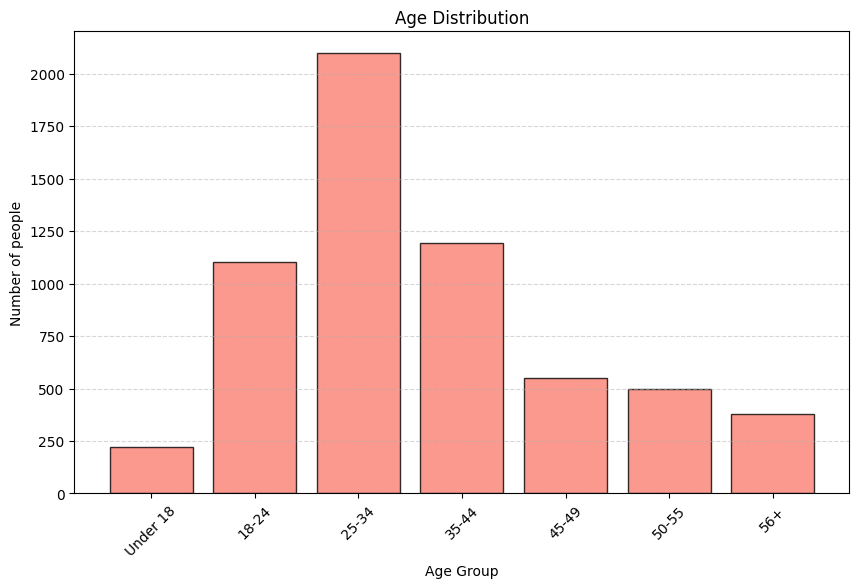

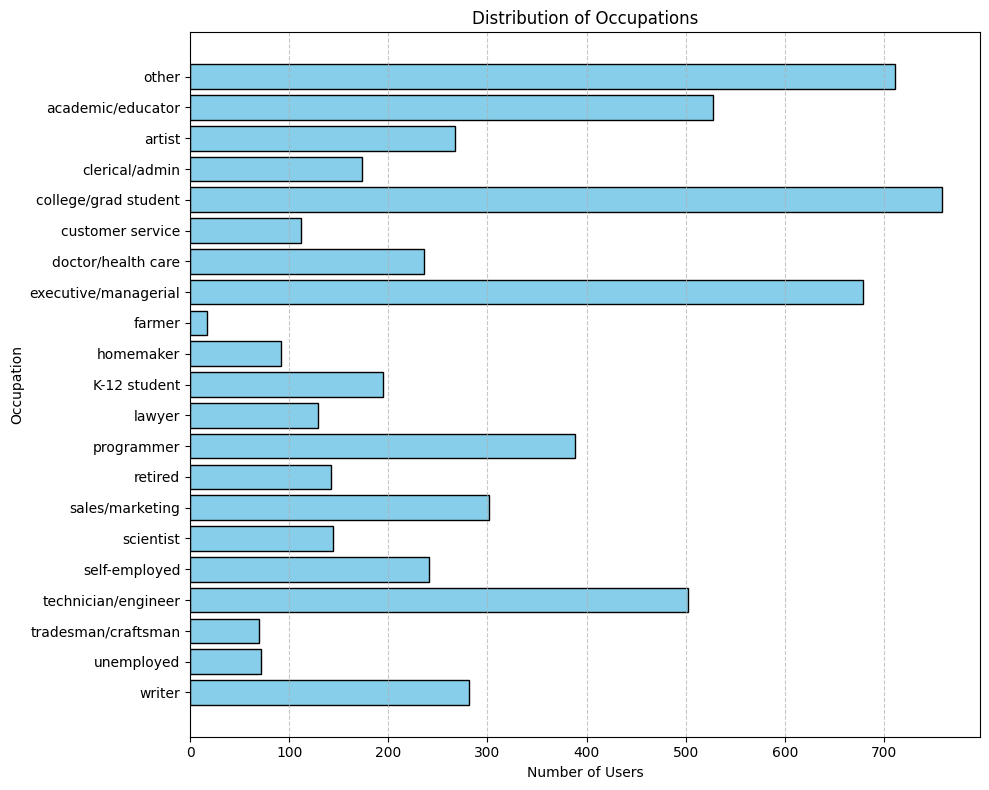

In [86]:
print("Small sample: ")
print(df_users.iloc[0:2], "\n") # sample 
print("Gender distribution")
print("There are ", int(df_users.groupby("Gender").size()["F"]), " females and ", int(df_users.groupby("Gender").size()["M"]), " males")

print("Age distribution: ")
age_mapping = {
    1:  "Under 18",
    18: "18-24",
    25: "25-34",
    35: "35-44",
    45: "45-49",
    50: "50-55",
    56: "56+"
}

age_counts = df_users['Age'].value_counts().sort_index()

age_labels = [age_mapping[age] for age in age_counts.index]

plt.figure(figsize=(10, 6))
plt.bar(age_labels, age_counts.values, color='salmon', edgecolor='black', alpha=0.8)

plt.title('Age Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of people')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.xticks(rotation=45)


occupation_mapping = {
    0: "other", 1: "academic/educator", 2: "artist", 3: "clerical/admin", 
    4: "college/grad student", 5: "customer service", 6: "doctor/health care",
    7: "executive/managerial", 8: "farmer", 9: "homemaker", 10: "K-12 student",
    11: "lawyer", 12: "programmer", 13: "retired", 14: "sales/marketing",
    15: "scientist", 16: "self-employed", 17: "technician/engineer",
    18: "tradesman/craftsman", 19: "unemployed", 20: "writer"
}

occ_counts = df_users['Occupation'].value_counts().sort_index()
occ_names = [occupation_mapping[i] for i in occ_counts.index]

plt.figure(figsize=(10, 8))
plt.barh(occ_names, occ_counts.values, color='skyblue', edgecolor='black')

plt.title('Distribution of Occupations')
plt.xlabel('Number of Users')
plt.ylabel('Occupation')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout() 



plt.show()

### interpretation
First of all its quite interesting that there are  1709  females compared to 4331  males, I would have expected 
a nearly 50/50 distribution. Probably this can be used for recommendations but opens up a new topic "can a recommender system be secist?", this means this topic should be handled carefully. 

Age distribution can definitely be used for recommendations, of course age limitations have to be considered e.g. no nsfw content for minors. But also in the other direction this works. Probably child movies are more interesting for people below 18 (and maybe for the older ones with kids again). 
But for this a more fine grain scale would be good, especially in the below 18 segment there are huge differences in preferences.

From the occupation there are also some information which can be used to a certain degree, probably action films are interesting for a variety of occupation and doesn't really depend on that. On the other hand documentations about certain topics could be particulary interesting for a subset of occupations. Maybe more creative films are more interesting to an artist compared to a farmer. 

## Analyze movie metadata (movies.dat):
• Distribution of genres.  
• Average number of genres per movie.  
• Discuss how metadata could help address cold start.  

In [87]:
# File file contains 3883 movies with MovieID, Title and Genres. 
df_movies = pd.read_csv("./data/movies.dat", 
                 sep='::', 
                 names=['Movie-ID','Title', 'Genres'], 
                 header=None)

C:\Users\jonas\AppData\Local\Temp\ipykernel_32248\3700697453.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_movies = pd.read_csv("./data/movies.dat",


Small sample: 
   Movie-ID             Title                        Genres
0         1  Toy Story (1995)   Animation|Children's|Comedy
1         2    Jumanji (1995)  Adventure|Children's|Fantasy


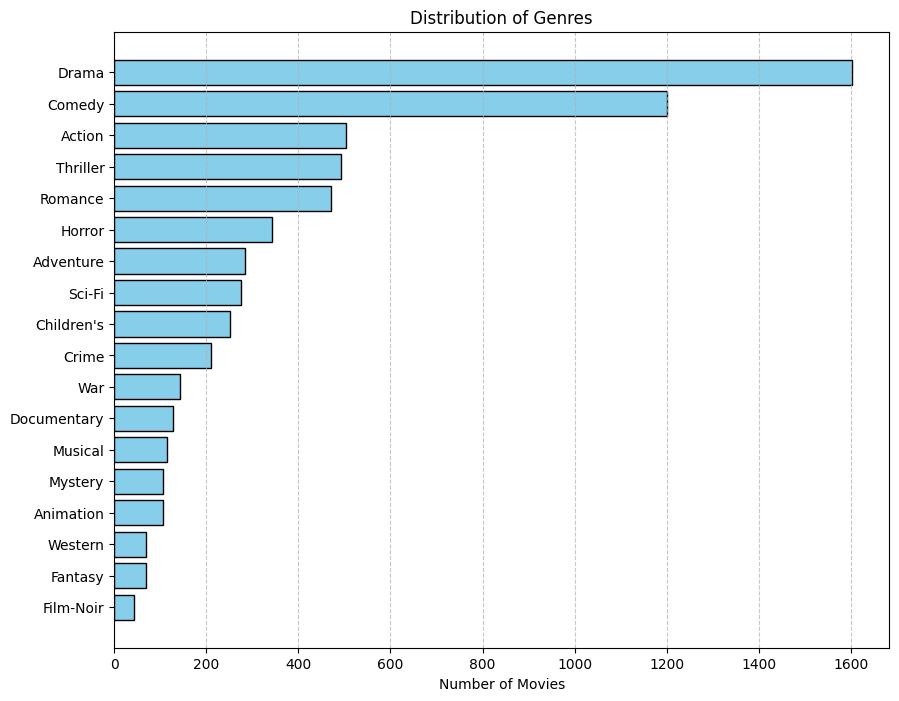

Average number of genres per movie: 1.65


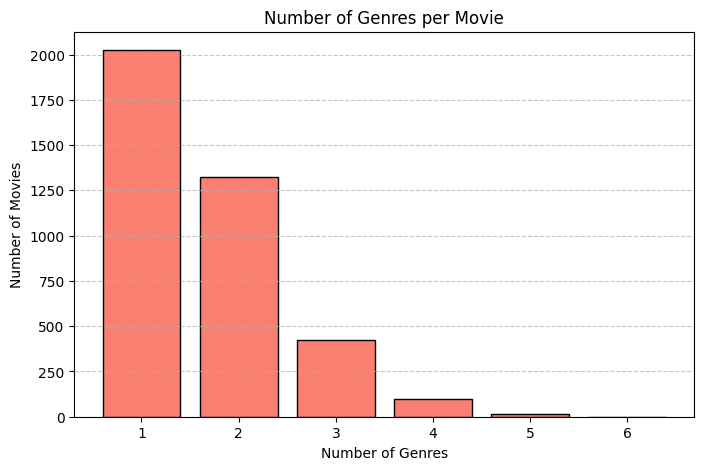

In [88]:
print("Small sample: ")
print(df_movies.iloc[0:2]) 



df_movies['Genre_List'] = df_movies['Genres'].str.split('|')

all_genres = df_movies.explode('Genre_List')
genre_counts = all_genres['Genre_List'].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(genre_counts.index, genre_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of Genres')
plt.xlabel('Number of Movies')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

df_movies['Genre_Count'] = df_movies['Genre_List'].apply(len)
avg_genres = df_movies['Genre_Count'].mean()
print(f"Average number of genres per movie: {avg_genres:.2f}")

genre_count_dist = df_movies['Genre_Count'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(genre_count_dist.index.astype(str), genre_count_dist.values, color='salmon', edgecolor='black')
plt.title('Number of Genres per Movie')
plt.xlabel('Number of Genres')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


### interpretion
I'm suprised about the distribution of genres, I would have expected a more balanced distribution. Especially that there are roughly 
10 times as many dramas as documentaries is surprising to me. 
I read that Drama is often times used as an extra category for genres like crime, romance or thriller and this is why it appears so often. 
In conclussion the drama tag doesn't give a lot of information just because someone likes horror (and is also labeled as drama) it doesn't mean he also likes thriller. On the other hand this could also helpful for the problem described in the next paragraph. 

The number of genres is as expected, most movies can be put into one clear category or fit into another as well. But there are not many films which have many different facettes. One problem whith the average number of genres of 1.65 is that there isn't a lot of overlapping between the categories (Label sparsity). Of course inside the category its easy but similar films in different categorys have no metadata connecting them. 
For example a horror film could be quite the same as a crime fan, from a label perspective they are completely unrelated. 

For the item cold start the metadata can be used, because the labels are not learned but added by the author (or plattform) they can be used directly to be grouped into a category and recommend it to users who like films from the same category. 

## e) Elaborate which of the features might be useful for a recommender system and why you think this is the case

I think there are two problems in that. First of all we have to find a connection between different movies, this can be done via the labels. Therefore the genres are definitely important. This especially helps for the cold start when new items are uploaded. Only later the system can learn user behaviour and connect movies without the labels.  
On the other hand we also have to group people together and recognise similar interests. For this age, gender and occupation can be relevant. (Also the zip code could be interesting for spezific topics)
I don't think that the number of ratings from the users can be used in any meaningful way to recommend better movies to him, on the other hand the amount of likes a user gives could be interesting to give the voting more (or less weight). A user who gives out 100 5-star reviews is probably not the most interesting, its much more interesting if someone who rarely gives out a 5-star rating does so for one film. 
The ratings from the movies on the other hand is a standard "recommend popular things", and many people will like it. 
